In [1]:
import pandas as pd
import numpy as np
from src.data.loader import load_parquet, prediction_long, prediction_short, assets_dir
from sklearn.metrics import mean_pinball_loss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
predictions_long = load_parquet(prediction_long)
predictions_short = load_parquet(prediction_short)

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

for q in quantiles:
    col = f"Quantile_{q}"
    loss_long = mean_pinball_loss(predictions_long["y_true"], predictions_long[col], alpha=q)
    loss_short = mean_pinball_loss(predictions_short["y_true"], predictions_short[col], alpha=q)
    print(f"Q{q} — Long: {loss_long:.4f} | Short: {loss_short:.4f}")


Q0.1 — Long: 5.3901 | Short: 6.4451
Q0.25 — Long: 9.1097 | Short: 10.4140
Q0.5 — Long: 11.9664 | Short: 12.4719
Q0.75 — Long: 10.8169 | Short: 9.8472
Q0.9 — Long: 6.4731 | Short: 5.9050


In [3]:
for q in quantiles:
    col = f"Quantile_{q}"

    baseline_long = np.quantile(predictions_long["y_true"], q)
    baseline_short = np.quantile(predictions_short["y_true"], q)

    loss_long = mean_pinball_loss(predictions_long["y_true"], predictions_long[col], alpha=q)
    loss_short = mean_pinball_loss(predictions_short["y_true"], predictions_short[col], alpha=q)

    baseline_loss_long = mean_pinball_loss(predictions_long["y_true"], np.full(len(predictions_long), baseline_long), alpha=q)
    baseline_loss_short = mean_pinball_loss(predictions_short["y_true"], np.full(len(predictions_short), baseline_short), alpha=q)

    skill_long = (1 - loss_long / baseline_loss_long) * 100
    skill_short = (1 - loss_short / baseline_loss_short) * 100

    print(f"Q{q} — Long: {loss_long:.4f} (skill: {skill_long:.1f}%) | Short: {loss_short:.4f} (skill: {skill_short:.1f}%)")

Q0.1 — Long: 5.3901 (skill: 18.1%) | Short: 6.4451 (skill: 20.6%)
Q0.25 — Long: 9.1097 (skill: 29.2%) | Short: 10.4140 (skill: 37.8%)
Q0.5 — Long: 11.9664 (skill: 39.3%) | Short: 12.4719 (skill: 35.0%)
Q0.75 — Long: 10.8169 (skill: 28.3%) | Short: 9.8472 (skill: 26.2%)
Q0.9 — Long: 6.4731 (skill: 18.3%) | Short: 5.9050 (skill: 18.0%)


## Pinball Loss & Skill Score

The pinball loss measures the accuracy of quantile predictions, lower is better.
The skill score indicates the percentage improvement over a naive baseline that always predicts
the empirical quantile of the training set.

| Quantile | Long Loss | Long Skill | Short Loss | Short Skill |
|----------|-----------|------------|------------|-------------|
| Q0.1     | 5.3901    | 18.1%      | 6.4451     | 20.6%       |
| Q0.25    | 9.1097    | 29.2%      | 10.4140    | 37.8%       |
| Q0.5     | 11.9664   | 39.3%      | 12.4719    | 35.0%       |
| Q0.75    | 10.8169   | 28.3%      | 9.8472     | 26.2%       |
| Q0.9     | 6.4731    | 18.3%      | 5.9050     | 18.0%       |

The model performs best around the median (Q0.5), with skill scores of ~39% for Long and ~35% for Short.
Performance is weaker at the tails (Q0.1, Q0.9) with ~18-20% improvement over baseline,
which is expected because extreme price events are harder to predict.

In [4]:
coverage = ((predictions_long["y_true"] >= predictions_long["Quantile_0.1"]) &
            (predictions_long["y_true"] <= predictions_long["Quantile_0.9"])).mean()
print(f"Coverage Long [Q0.1-Q0.9]: {coverage:.1%} (expected: 80%)")

coverage_short = ((predictions_short["y_true"] >= predictions_short["Quantile_0.1"]) &
                  (predictions_short["y_true"] <= predictions_short["Quantile_0.9"])).mean()
print(f"Coverage Short [Q0.1-Q0.9]: {coverage_short:.1%} (expected: 80%)")


width_long = (predictions_long["Quantile_0.9"] - predictions_long["Quantile_0.1"]).mean()
width_short = (predictions_short["Quantile_0.9"] - predictions_short["Quantile_0.1"]).mean()
print(f"Average width interval Long: {width_long:.2f} €/MWh")
print(f"Average width interval Short: {width_short:.2f} €/MWh")


bias_long = (predictions_long["y_true"] - predictions_long["Quantile_0.5"]).mean()
bias_short = (predictions_short["y_true"] - predictions_short["Quantile_0.5"]).mean()
print(f"Bias median Long: {bias_long:.2f} €/MWh")
print(f"Bias median Short: {bias_short:.2f} €/MWh")

Coverage Long [Q0.1-Q0.9]: 74.3% (expected: 80%)
Coverage Short [Q0.1-Q0.9]: 75.3% (expected: 80%)
Average width interval Long: 70.74 €/MWh
Average width interval Short: 75.63 €/MWh
Bias median Long: 7.11 €/MWh
Bias median Short: -2.96 €/MWh


## Calibration Analysis

### Coverage
A well-calibrated quantile model should have ~80% of true values falling within the [Q0.1, Q0.9] interval.
Our model achieves 74.3% for Long price and 75.3% for Short price,
slightly below the 80% target, indicating the model's prediction intervals are slightly too narrow,
more true values fall outside the [Q0.1, Q0.9] interval than expected.

### Interval Width
The average prediction interval width is 70.74 €/MWh for Long and 75.63 €/MWh for Short.
This wide interval reflects the inherent volatility of Spanish imbalance prices.

### Median Bias
The Long price model shows a systematic bias of 7.11 €/MWh, the model consistently
underestimates Long prices. The Short price bias of -2.96 €/MWh is more acceptable.
The monthly breakdown below investigates whether this bias is concentrated on specific periods.

# Plots

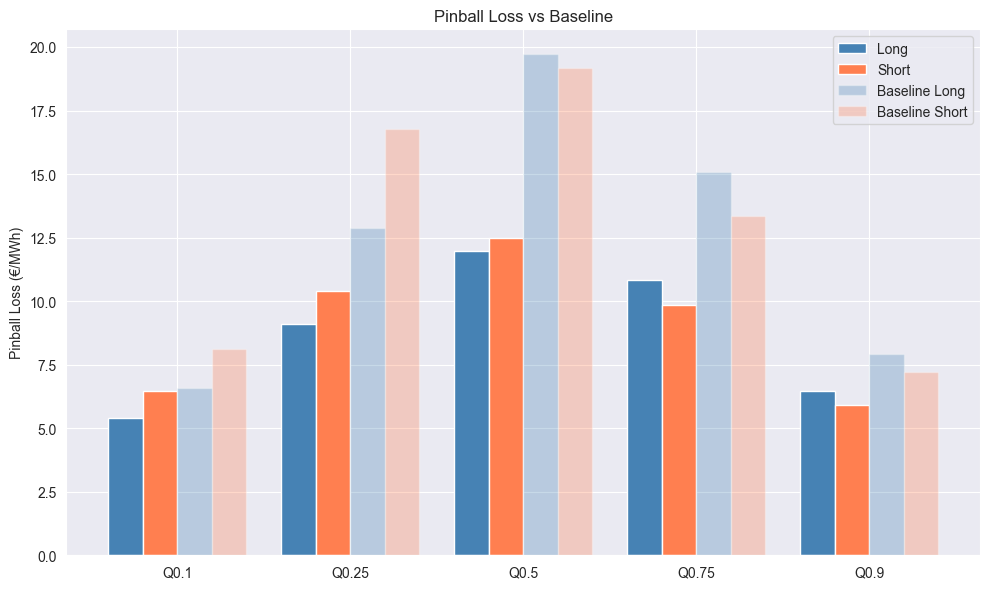

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
losses_long = [mean_pinball_loss(predictions_long["y_true"], predictions_long[f"Quantile_{q}"], alpha=q) for q in quantiles]
losses_short = [mean_pinball_loss(predictions_short["y_true"], predictions_short[f"Quantile_{q}"], alpha=q) for q in quantiles]
baseline_long = [mean_pinball_loss(predictions_long["y_true"], np.full(len(predictions_long), np.quantile(predictions_long["y_true"], q)), alpha=q) for q in quantiles]
baseline_short = [mean_pinball_loss(predictions_short["y_true"], np.full(len(predictions_short), np.quantile(predictions_short["y_true"], q)), alpha=q) for q in quantiles]

x = np.arange(len(quantiles))
width = 0.2
ax.bar(x - width*1.5, losses_long, width, label="Long", color="steelblue")
ax.bar(x - width*0.5, losses_short, width, label="Short", color="coral")
ax.bar(x + width*0.5, baseline_long, width, label="Baseline Long", color="steelblue", alpha=0.3)
ax.bar(x + width*1.5, baseline_short, width, label="Baseline Short", color="coral", alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels([f"Q{q}" for q in quantiles])
ax.set_title("Pinball Loss vs Baseline")
ax.set_ylabel("Pinball Loss (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(assets_dir / "Pinball_loss_vs_Baseline.png", dpi=150, bbox_inches="tight")

## Pinball Loss vs Baseline

The chart compares the pinball loss of the model against the naive baseline for both Long and Short prices.
Across all quantiles, the model consistently outperforms the baseline, the improvement is most visible
around Q0.25-Q0.75 where the model has the most signal to exploit. At the tails (Q0.1, Q0.9) the gap
narrows, which is expected since extreme price spikes are harder to anticipate.

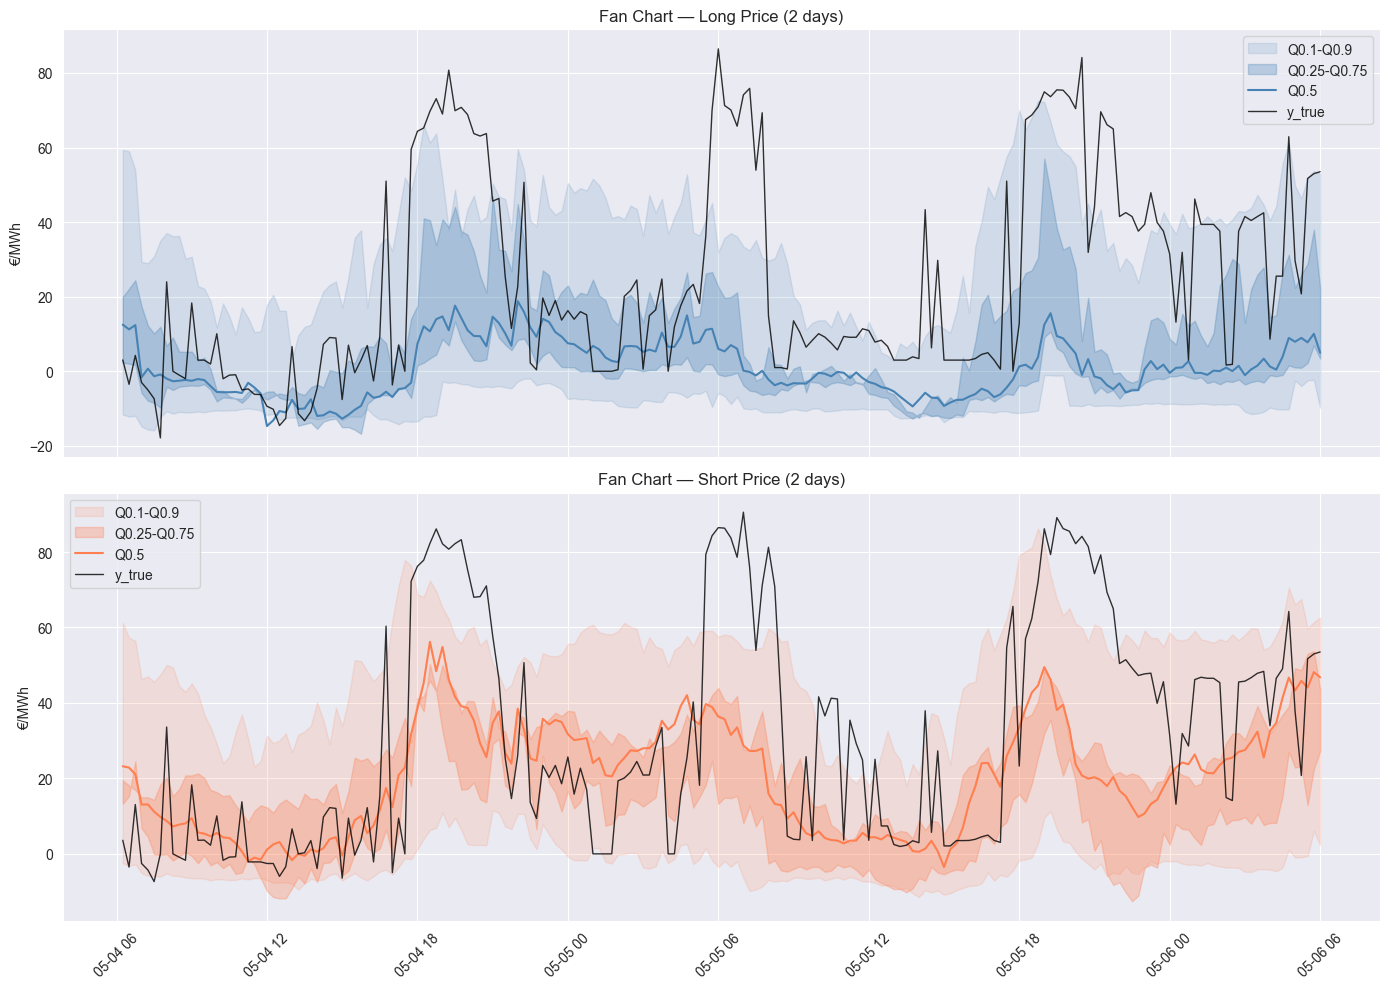

In [6]:
n_periods = 2 * 24 * 4
sample_long = predictions_long.iloc[3000:n_periods + 3000]
sample_short = predictions_short.iloc[3000:n_periods + 3000]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, sample, title, color in zip(axes,
                                     [sample_long, sample_short],
                                     ["Long Price", "Short Price"],
                                     ["steelblue", "coral"]):
    ax.fill_between(sample.index, sample["Quantile_0.1"], sample["Quantile_0.9"], alpha=0.15, color=color, label="Q0.1-Q0.9")
    ax.fill_between(sample.index, sample["Quantile_0.25"], sample["Quantile_0.75"], alpha=0.3, color=color, label="Q0.25-Q0.75")
    ax.plot(sample.index, sample["Quantile_0.5"], color=color, linewidth=1.5, label="Q0.5")
    ax.plot(sample.index, sample["y_true"], color="black", linewidth=1, alpha=0.8, label="y_true")
    ax.set_title(f"Fan Chart — {title} (2 days)")
    ax.set_ylabel("€/MWh")
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(assets_dir / "Fan_chart_2_days.png", dpi=150, bbox_inches="tight")

## Fan Chart — Prediction Intervals

The fan chart shows the model's uncertainty estimates over a 2-day window. The lighter band represents
the Q0.1-Q0.9 interval, the darker band Q0.25-Q0.75, and the black line the true observed price.

Most of the time the true price stays within the intervals, but extreme spikes fall outside,
these are sudden imbalance events that are structurally hard to predict from day-ahead and intraday
forecasts alone. This also explains the 74-75% coverage vs the expected 80%.

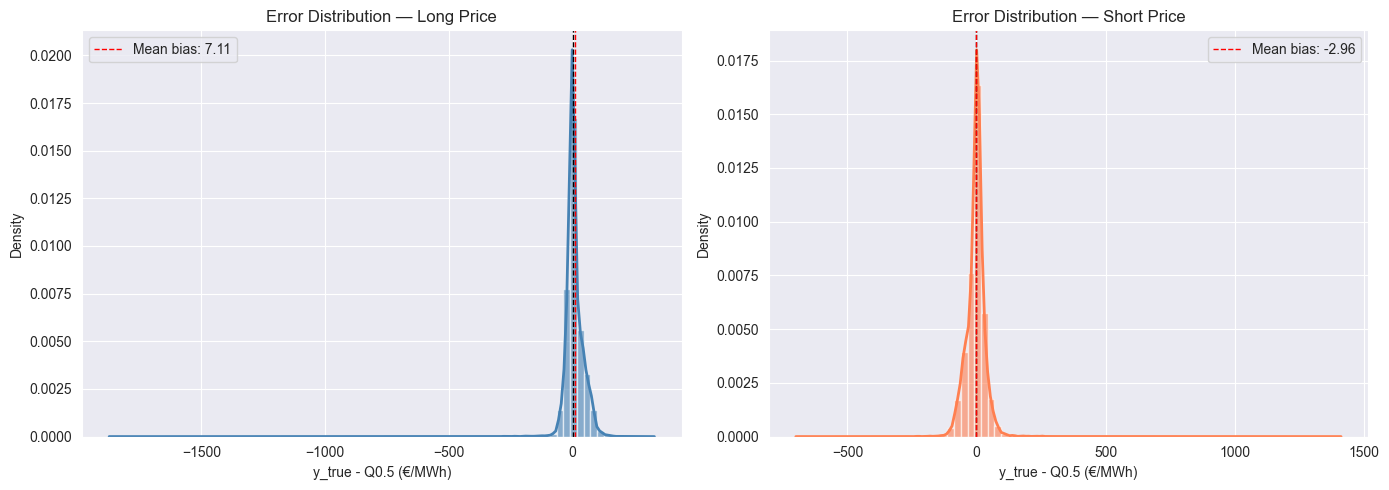

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errors_long = predictions_long["y_true"] - predictions_long["Quantile_0.5"]
errors_short = predictions_short["y_true"] - predictions_short["Quantile_0.5"]

for ax, errors, title, color in zip(axes,
                                     [errors_long, errors_short],
                                     ["Long Price", "Short Price"],
                                     ["steelblue", "coral"]):
    ax.hist(errors, bins=80, alpha=0.6, color=color, density=True)
    sns.kdeplot(errors, ax=ax, color=color, linewidth=2)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(errors.mean(), color="red", linestyle="--", linewidth=1, label=f"Mean bias: {errors.mean():.2f}")
    ax.set_title(f"Error Distribution — {title}")
    ax.set_xlabel("y_true - Q0.5 (€/MWh)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig(assets_dir / "Error_distribution.png", dpi=150, bbox_inches="tight")

In [8]:
print(errors_long.describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

count    31680.000000
mean         7.111281
std         37.667613
min      -1857.898265
1%         -62.605190
5%         -36.559968
95%         70.445644
99%        100.756665
max        315.533130
dtype: float64


## Error Distribution

The error distribution looks Gaussian at first glance, but the tails tell a different story.
Min error hits -1857 €/MWh, max 315 €/MWh, std of 37 €/MWh.\
The [-62, +100] €/MWh range
covers the normal regime well, outside of that, the model has no chance given the 4h information
lag and prediction horizon.

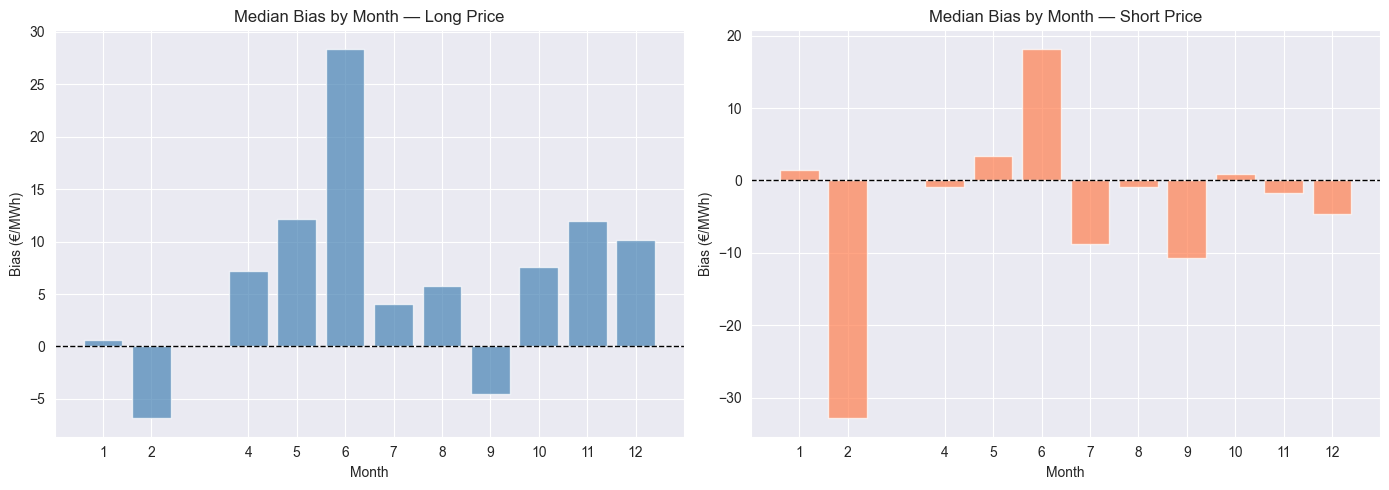

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errors_long = predictions_long["y_true"] - predictions_long["Quantile_0.5"]
errors_short = predictions_short["y_true"] - predictions_short["Quantile_0.5"]

bias_by_month_long = errors_long.groupby(predictions_long.index.month).mean()
bias_by_month_short = errors_short.groupby(predictions_short.index.month).mean()

for ax, bias, title, color in zip(axes,
                                   [bias_by_month_long, bias_by_month_short],
                                   ["Long Price", "Short Price"],
                                   ["steelblue", "coral"]):
    ax.bar(bias.index, bias.values, color=color, alpha=0.7)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Median Bias by Month — {title}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Bias (€/MWh)")
    ax.set_xticks(bias.index)

plt.tight_layout()
plt.savefig(assets_dir / "Median_bias.png", dpi=150, bbox_inches="tight")

## Median Bias by Month

No clear seasonal pattern emerges, some months are overestimated, others underestimated, without any consistent trend across seasons. \
This suggests the +7.11 €/MWh overall bias on Long price is not driven by a specific period but rather by isolated extreme events that pull the mean upward.